In [10]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.datasets import make_classification
from sklearn.model_selection import KFold, train_test_split
from sklearn.inspection import permutation_importance
import matplotlib.pyplot as plt

In [2]:
torch.manual_seed(42)
np.random.seed(42)


Data preparation and split



In [3]:
X, y = make_classification(
    n_samples=5000, n_features=20, n_classes=4, n_informative=4, random_state=42
)

X = torch.tensor(X, dtype=torch.float32)
y = torch.tensor(y, dtype=torch.long)

X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

Model's definition and Cross Validation

In [4]:
class SimpleClassifier(nn.Module):
  def __init__(self, input_dim, output_dim):
    super().__init__()
    self.net = nn.Sequential(
        nn.Linear(input_dim, 64),
        nn.ReLU(),
        nn.Linear(64, 32),
        nn.ReLU(),
        nn.Linear(32, output_dim)
    )
  def forward(self, x):
      return self.net(x)

In [5]:
kf = KFold(n_splits=3, shuffle=True, random_state=42)
trained_models = []

In [6]:
for fold, (train_idx, val_idx) in enumerate(kf.split(X_train_val)):
  X_tr, y_tr = X_train_val[train_idx], y_train_val[train_idx]
  X_va, y_va = X_train_val[val_idx], y_train_val[val_idx]

  model = SimpleClassifier(input_dim=20, output_dim=4)
  criterion = nn.CrossEntropyLoss()
  optimizer = optim.Adam(model.parameters(), lr=0.01)

  best_val_loss = float('inf')
  best_model_state = None

  for epoch in range(50):
    model.train()
    optimizer.zero_grad()
    outputs = model(X_tr)
    loss = criterion(outputs, y_tr)
    loss.backward()
    optimizer.step()

    model.eval()
    with torch.no_grad():
      val_outputs = model(X_va)
      val_loss = criterion(val_outputs, y_va).item()

    if val_loss < best_val_loss:
      best_val_loss = val_loss
      best_model_state = model.state_dict().copy()

  best_model = SimpleClassifier(input_dim=20, output_dim=4)
  best_model.load_state_dict(best_model_state)
  best_model.eval()
  trained_models.append(best_model)

In [13]:
class PyTorchEnsambleWrapper:
  def __init__(self, models):
    self.models = models
    self.classes_ = np.array([0, 1, 2, 3])

  def fit(self, X, y):
    pass

  def predict(self, X):
    if isinstance(X, np.ndarray):
      X = torch.tensor(X, dtype=torch.float32)

    all_preds = []

    with torch.no_grad():
      for model in self.models:
        logits = model(X)
        probs = torch.softmax(logits, dim=1)
        all_preds.append(probs.numpy())

    ensemble_probs = np.mean(all_preds, axis=0)
    return np.argmax(ensemble_probs, axis=1)

  def score(self, X, y):
    y_pred = self.predict(X)
    if isinstance(y, torch.Tensor):
        y = y.numpy()
    return np.mean(y_pred == y)

In [14]:
clf = PyTorchEnsambleWrapper(trained_models)

X_train_val_np = X_train_val.numpy()
y_train_val_np = y_train_val.numpy()
X_test_np = X_test.numpy()
y_test_np = y_test.numpy()

In [15]:
r_train = permutation_importance(clf, X_train_val_np, y_train_val_np, n_repeats=100, random_state=0)
r_test = permutation_importance(clf, X_test_np, y_test_np, n_repeats=100, random_state=0)

In [16]:
def analyze_importance(r, dataset_name):
    print(f"\n--- Analiza dla zbioru: {dataset_name} ---")
    significant_features = []
    negative_features = []

    for i in range(X.shape[1]):
        # Wyznaczanie 95%-owego przedziału ufności metodą percentyli
        low_bound = np.percentile(r.importances[i], 2.5)
        high_bound = np.percentile(r.importances[i], 97.5)
        mean_imp = r.importances_mean[i]

        # Cecha jest istotna, jeśli przedział NIE zawiera zera
        if not (low_bound <= 0 <= high_bound):
            significant_features.append(i)
        if mean_imp < 0:
            negative_features.append((i, mean_imp))

    print(f"Cechy istotne statystycznie (95% CI nie zawiera 0): {significant_features}")
    print(f"Cechy z ujemnym 'importance': {negative_features}")

analyze_importance(r_train, "Train+Val")
analyze_importance(r_test, "Test")


--- Analiza dla zbioru: Train+Val ---
Cechy istotne statystycznie (95% CI nie zawiera 0): [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19]
Cechy z ujemnym 'importance': []

--- Analiza dla zbioru: Test ---
Cechy istotne statystycznie (95% CI nie zawiera 0): [6, 8, 9, 13, 14, 15, 18]
Cechy z ujemnym 'importance': [(0, np.float64(-0.007750000000000007)), (4, np.float64(-0.002630000000000002)), (7, np.float64(-0.0016400000000000015)), (11, np.float64(-0.0015000000000000013)), (12, np.float64(-0.0030200000000000027)), (15, np.float64(-0.007670000000000007)), (16, np.float64(-0.003420000000000003)), (19, np.float64(-0.001160000000000001))]


/tmp/ipykernel_3022/379748680.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


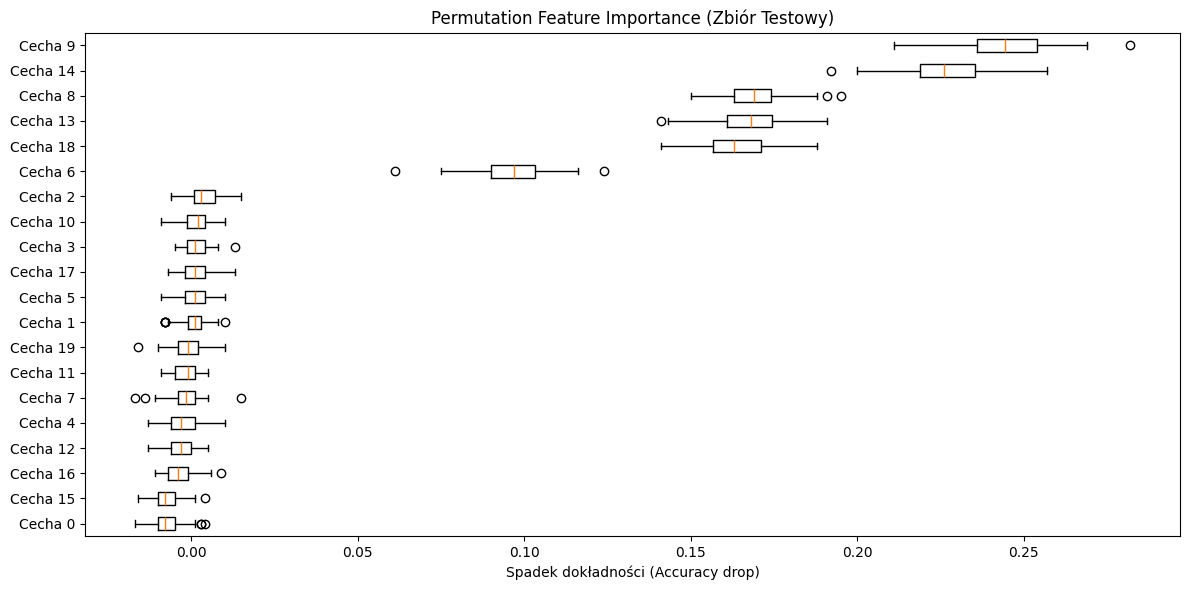

In [17]:
sorted_importances_idx = r_test.importances_mean.argsort()

plt.figure(figsize=(12, 6))
plt.boxplot(
    r_test.importances[sorted_importances_idx].T,
    vert=False,
    labels=[f"Cecha {i}" for i in sorted_importances_idx],
)
plt.title("Permutation Feature Importance (Zbiór Testowy)")
plt.xlabel("Spadek dokładności (Accuracy drop)")
plt.tight_layout()
plt.show()